In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import datasets, manifold
%matplotlib inline


In [7]:
import ssl
import urllib.request

ssl._create_default_https_context = ssl._create_unverified_context
response = urllib.request.urlopen('https://example.com')


In [ ]:
# response

<Response [200]>

In [9]:
# data = datasets.fetch_openml("mnist_784",version=1,return_X_y=True)
housing_data = pd.read_csv("/Users/user/Documents/housing/housing.csv")

In [12]:
housing_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [14]:
housing_data["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [16]:
housing_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


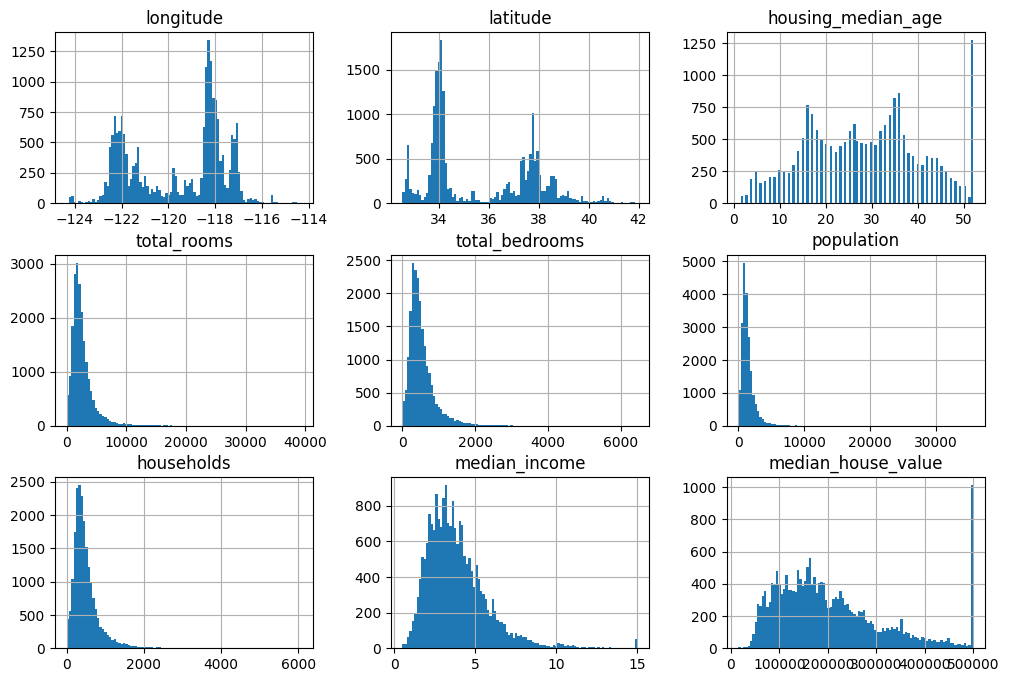

In [22]:
housing_data.hist(bins=100,figsize=(12,8))
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing_data,test_size=0.2,random_state=42)

In [28]:
# convert features to categorical features.
housing_data["income_cat"] = (pd.cut(housing_data["median_income"],bins=[0,1.5,3,4.5,6,np.inf],labels=[1,2,3,4,5]))

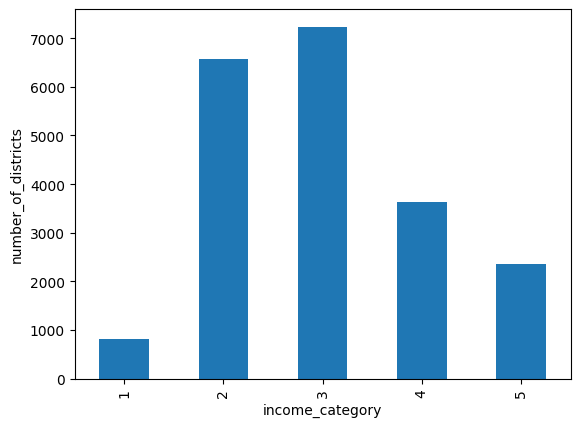

In [31]:
housing_data["income_cat"].value_counts().sort_index().plot.bar()
plt.xlabel("income_category")
plt.ylabel("number_of_districts")
plt.show()

In [34]:
# stratified train test set creation and also creating data for cross_validation.
from sklearn.model_selection import StratifiedShuffleSplit
splitter = StratifiedShuffleSplit(n_splits=10,test_size=0.2,random_state=9)
strat_splits = []
for split_train_idx,split_test_idx in splitter.split(housing_data,housing_data["income_cat"]):
    train_data = housing_data.iloc[split_train_idx]
    test_data = housing_data.iloc[split_test_idx]
    strat_splits.append([train_data,test_data])


In [37]:
#simply
train_data,test_data = train_test_split(housing_data,test_size=0.2,stratify=housing_data["income_cat"],random_state=42)

In [ ]:
test_data["income_cat"].value_counts()/

income_cat
3    1447
2    1316
4     728
5     472
1     165
Name: count, dtype: int64

In [40]:
#droping a column from df
for data_set in (train_data,test_data):
    data_set.drop("income_cat",axis=1,inplace=True)

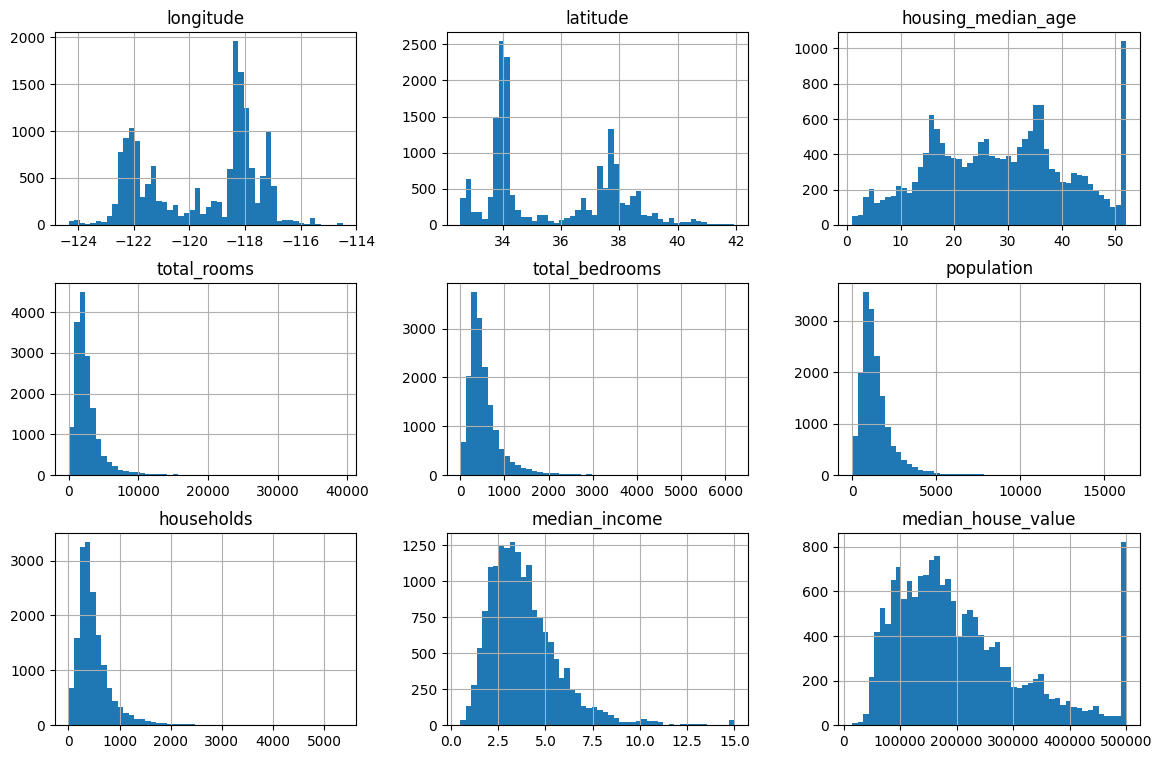

In [ ]:
train_data.hist(bins = 50,figsize=(14,9))
# plt.show()

Data visualization

In [45]:
housing = train_data.copy()

<Axes: xlabel='longitude', ylabel='latitude'>

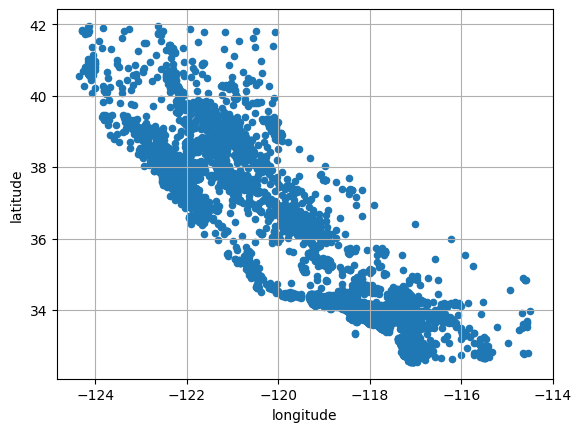

In [47]:
housing.plot(kind="scatter",x="longitude",y="latitude",grid=True)

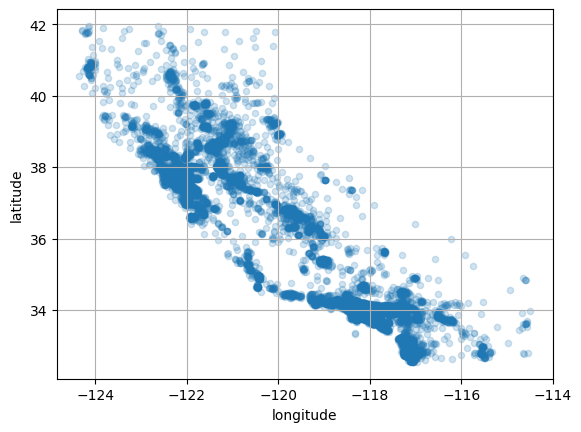

In [52]:
#change alpha to see the high density of the points.
housing.plot(kind="scatter",x="longitude",y="latitude",grid=True,alpha=0.2)
plt.show()

In [55]:
#look for correlations(simple way of feature selection)
corr_matrics = housing.corr(numeric_only=True)

In [56]:
corr_matrics["median_house_value"].sort_values()

latitude             -0.139584
longitude            -0.050859
population           -0.020153
total_bedrooms        0.054635
households            0.071426
housing_median_age    0.102175
total_rooms           0.137455
median_income         0.688380
median_house_value    1.000000
Name: median_house_value, dtype: float64

In [ ]:
# use pandas scatter_matrix to plot the correlation